# Análisis y Modelamiento: Determinantes de Salud Mental en Bogotá

**DataJam Edición 3 — 2026** | Equipo GEMMA 2.0

Este notebook consume los artefactos procesados en `001_pre_processing.ipynb`
para calcular indicadores epidemiológicos, explorar la relación entre
infraestructura verde y conducta suicida, y estimar un modelo de regresión
logística sobre los determinantes de la salud autopercibida.

**Pregunta analítica:** ¿En qué medida la infraestructura verde disponible por
localidad y los factores estructurales del hogar (composición familiar, carga
de cuidado, rol dentro del hogar) se asocian con indicadores de salud mental
en Bogotá?

**Hipótesis:** la vulnerabilidad en salud mental no depende de un único factor,
sino de la convergencia de condiciones territoriales y condiciones estructurales
del hogar.

### 1. Instalación de dependencias.

In [ ]:
import os
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

from google.colab import drive

warnings.filterwarnings("ignore")

In [ ]:
drive.mount("/content/drive")

Mounted at /content/drive


### 1.1 Inicialización de rutas del proyecto (preservando las previamente establecidas)

In [ ]:
# Definición de rutas del proyecto
PROJECT_NAME = "prueba" # Indique el nombre de la carpeta anteriormente creada en el notebook 001
PROJECT_PATH = f"/content/drive/MyDrive/{PROJECT_NAME}/"
RAW_DATA_PATH = os.path.join(PROJECT_PATH, "data/raw/")
PROCESSED_DATA_PATH = os.path.join(PROJECT_PATH, "data/processed/")
OUTPUTS_FIG_PATH = os.path.join(PROJECT_PATH, "outputs/figures/")
OUTPUTS_TABLE_PATH = os.path.join(PROJECT_PATH, "outputs/tables/")

print(f"Inicialización del Entorno 002 completada.\n")

Inicialización del Entorno 002 completada.



### 1.2 Verificación de prerrequisitos generados por el Notebook 001.

In [ ]:
REQUIRED_FILES = [
    os.path.join(PROCESSED_DATA_PATH, "master_mental_health_bogota_2025.geojson"),
    os.path.join(PROCESSED_DATA_PATH, "suicide_events_clean.csv"),
    os.path.join(PROCESSED_DATA_PATH, "perception_survey_clean.csv"),
]

missing_files = [f for f in REQUIRED_FILES if not os.path.exists(f)]

if missing_files:
    print("No se encontraron los archivos necesarios para ejecutar este notebook:\n")
    for f in missing_files:
        print(f"   - {f}")
    print(
        "\nEstos archivos son generados por el notebook '001_pre_processing.ipynb'.\n"
        "Antes de continuar con este notebook (002), asegúrate de:\n"
        "  1. Abrir 'notebooks/001_pre_processing.ipynb'.\n"
        "  2. Ejecutarlo COMPLETO, de principio a fin, sin saltar celdas.\n"
        "  3. Confirmar que la ruta de proyecto en Drive coincide con la de este notebook:\n"
        f"       {PROJECT_PATH}\n"
        "  4. Volver a ejecutar esta celda para verificar que ya estén disponibles.\n"
    )
    raise FileNotFoundError(
        "Faltan archivos de entrada generados por el notebook 001. "
        "Ejecuta primero '001_pre_processing.ipynb' de principio a fin."
    )
else:
    print("Todos los archivos necesarios del notebook 001 están disponibles. Puedes continuar.")

Todos los archivos necesarios del notebook 001 están disponibles. Puedes continuar.


### 2. Carga de artefactos procesados

Se cargan los tres artefactos exportados por el Notebook 1: el GeoDataFrame maestro agregado por localidad, los microdatos de suicidios consumados y los microdatos depurados de la Encuesta de Percepción 2025, que servirán de insumo para los análisis y el modelo econométrico de las siguientes secciones.

In [ ]:
# 2.1 Conjunto de datos espacial maestro (Agregado a nivel de localidad/UPL)
master_gdf = gpd.read_file(
    os.path.join(
        PROCESSED_DATA_PATH, "master_mental_health_bogota_2025.geojson")
)

# 2.2 Microdatos depurados de suicidios consumados (Fila por evento)
suicide_events_df = pd.read_csv(
    os.path.join(PROCESSED_DATA_PATH, "suicide_events_clean.csv"),
    encoding="utf-8-sig",
    low_memory=False,
)

# 2.3 Microdatos depurados de la Encuesta de Percepción 2025 (Fila por persona encuestada)
perception_microdata_df = pd.read_csv(
    os.path.join(PROCESSED_DATA_PATH, "perception_survey_clean.csv"),
    encoding="utf-8-sig",
    low_memory=False,
)

print(f"Capa espacial maestra cargada: {len(master_gdf)} entidades territoriales.")
print(f"Registros de microdatos listos para el modelado econométrico.")

Capa espacial maestra cargada: 20 entidades territoriales.
Registros de microdatos listos para el modelado econométrico.


### 3. Cálculo de indicadores epidemiológicos (Periodo 2023-2025)

Se consolida `suicide_summary_df` a partir de `master_gdf`, que ya contiene los indicadores de conducta suicida agregados por localidad calculados en el Notebook 1. Se renombran las columnas a la convención utilizada en el resto del análisis y el dashboard (`hombre`, `mujer`, `total_suicides_2023_2025`), y se exporta la tabla resumen resultante.

In [ ]:
# 3.1 Consolidación de indicadores epidemiológicos (fuente única: master_gdf, generado en Notebook 001)
suicide_summary_df = master_gdf.drop(columns="geometry")[
    ["locality_clean", "hombre", "mujer", "total_suicides_2023_2025"]
].copy()

suicide_summary_df = suicide_summary_df.rename(columns={
    "locality_clean": "LOCALIDAD_DEL_HECHO",
})

# 3.2 Exportar la tabla resumen
suicide_summary_df.to_csv(
    os.path.join(OUTPUTS_TABLE_PATH, "suicide_summary_by_locality_2023_2025.csv"),
    index=False,
    encoding="utf-8-sig"
)

print(f"Indicadores epidemiológicos consolidados desde master_gdf (n={len(suicide_summary_df)}).")
suicide_summary_df

Indicadores epidemiológicos consolidados desde master_gdf (n=20).


,LOCALIDAD_DEL_HECHO,hombre,mujer,total_suicides_2023_2025
0,ANTONIO NARINO,7.0,5.0,12.0
1,TUNJUELITO,22.0,10.0,32.0
2,RAFAEL URIBE URIBE,30.0,13.0,43.0
3,LA CANDELARIA,3.0,2.0,5.0
4,BARRIOS UNIDOS,16.0,5.0,21.0
5,TEUSAQUILLO,27.0,10.0,37.0
6,PUENTE ARANDA,22.0,5.0,27.0
7,LOS MARTIRES,6.0,4.0,10.0
8,SUMAPAZ,0.0,0.0,0.0
9,USAQUEN,75.0,19.0,94.0


### 4. Modelo econométrico: determinantes estructurales de salud deficiente

Se estima un modelo de regresión logística binaria sobre la variable de salud autopercibida (`poor_health`, derivada de `IND_SALUD_101`), con tamaño del hogar (A3), menores de 18 años a cargo (A4) y parentesco con el jefe de hogar (A6X2) como predictores. A6X2 se especifica como variable categórica (`C()`), dado que sus códigos representan categorías nominales de parentesco sin orden real, con "Jefe del hogar" como categoría de referencia.

Se calculan además los efectos marginales promedio (AME) para expresar los resultados en puntos porcentuales, y se generan tablas de coeficientes y efectos marginales con nombres de variable legibles, listas para el dashboard.

In [ ]:
# 4.1 Definición de la variable dependiente binaria
perception_microdata_df["poor_health"] = perception_microdata_df[
    "IND_SALUD_101"
].astype(int)

# 4.2 Selección y filtrado de variables explicativas clave
model_vars = ["poor_health", "A3", "A4", "A5", "A6X2"]

# Crear dataframe filtrado sin valores nulos ni códigos de No Responde (>90)
df_logit = perception_microdata_df[model_vars].copy()
df_logit = df_logit.dropna()

# 4.3 Especificación del modelo (Omitimos A5 como categoría de referencia)
# Al omitir A5, rompemos la multicolinealidad perfecta y A5 se vuelve la base de comparación.
logit_formula = "poor_health ~ A3 + A4 + C(A6X2, Treatment(reference=0))"

logit_model = smf.logit(formula=logit_formula, data=df_logit).fit(
    method="newton", maxiter=100
)
print(logit_model.summary())

# 4.5 Cálculo de los Efectos Marginales Promedio (AME)
try:
    ame_summary = logit_model.get_margeff(at="overall")
    print("\n=== EFECTOS MARGINALES PROMEDIO (AME) ===")
    print(ame_summary.summary())
except Exception as e:
    print(f"\nNota AME: {e}")

# 4.6 Diccionario de etiquetas para categorías de A6X2 (parentesco con jefe de hogar)
a6x2_labels = {
    0: "Jefe del hogar (referencia)",
    1: "Cónyuge",
    2: "Hija(o)",
    3: "Nuera/yerno",
    4: "Nieta(o)",
    5: "Padre/madre",
    6: "Suegra(o)",
    7: "Hermana(o)",
    8: "Cuñada(o)",
    9: "Pariente",
    10: "No pariente",
}

def clean_variable_name(raw_name):
    """Convierte nombres técnicos de statsmodels en etiquetas legibles."""
    if raw_name == "Intercept":
        return "Intercepto"
    if raw_name == "A3":
        return "A3 — N° personas en el hogar"
    if raw_name == "A4":
        return "A4 — N° menores de 18 años en el hogar"
    if "A6X2" in raw_name:
        code = int(float(raw_name.split("T.")[1].replace("]", "")))
        return f"A6x2 — {a6x2_labels[code]}"
    return raw_name

# 4.7 Tabla de coeficientes con nombres legibles
model_results_df = pd.DataFrame(
    {
        "Coeficiente": logit_model.params,
        "Error_Estandard": logit_model.bse,
        "P_Value": logit_model.pvalues,
        "Odds_Ratio": np.exp(logit_model.params),
    }
)
model_results_df = model_results_df.reset_index().rename(columns={"index": "Variable_raw"})
model_results_df["Variable"] = model_results_df["Variable_raw"].apply(clean_variable_name)
model_results_df = model_results_df.drop(columns=["Variable_raw"])

model_results_df.to_csv(
    f"{PROCESSED_DATA_PATH}model_coefficients.csv",
    index=False,
    encoding="utf-8-sig",
)

# 4.8 Tabla de efectos marginales (AME) con nombres legibles
ame_df = ame_summary.summary_frame().reset_index()
ame_df.columns = ["Variable_raw", "Efecto_Marginal", "Error_Estandar", "Z", "P_Value", "IC_2.5", "IC_97.5"]
ame_df["Variable"] = ame_df["Variable_raw"].apply(clean_variable_name)
ame_df = ame_df.drop(columns=["Variable_raw"])

ame_df.to_csv(
    f"{PROCESSED_DATA_PATH}ame_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

# 4.9 Estadísticos de ajuste del modelo
model_fit_stats = pd.DataFrame([{
    "N_obs": int(logit_model.nobs),
    "Pseudo_R2": logit_model.prsquared,
    "Log_Likelihood": logit_model.llf,
    "LLR_pvalue": logit_model.llr_pvalue,
}])
model_fit_stats.to_csv(
    f"{PROCESSED_DATA_PATH}model_fit_stats.csv",
    index=False,
    encoding="utf-8-sig",
)

# 4.10 Mantener también el export original a outputs/tables (para el repositorio técnico)
model_results_df.to_csv(
    os.path.join(OUTPUTS_TABLE_PATH, "logit_model_health_determinants.csv"),
    index=False,
    encoding="utf-8-sig",
)

print(f"\nResultados econométricos exportados exitosamente a:")
print(f"  - {PROCESSED_DATA_PATH} (model_coefficients.csv, ame_summary.csv, model_fit_stats.csv)")
print(f"  - {OUTPUTS_TABLE_PATH} (logit_model_health_determinants.csv)")

Optimization terminated successfully.
         Current function value: 0.603023
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:            poor_health   No. Observations:                13082
Model:                          Logit   Df Residuals:                    13069
Method:                           MLE   Df Model:                           12
Date:                Fri, 28 Aug 2026   Pseudo R-squ.:                 0.01162
Time:                        03:05:15   Log-Likelihood:                -7888.8
converged:                       True   LL-Null:                       -7981.5
Covariance Type:            nonrobust   LLR p-value:                 3.246e-33
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                   0.8003

### 5. Generación de cartografía temática (Infraestructura Verde Bogotá)

Se genera un mapa coroplético de la superficie total de áreas verdes por
localidad, proyectado a MAGNA-SIRGAS Origen Nacional (EPSG:9377) para
evitar distorsión visual en el territorio, y se exporta en alta resolución
para su uso en materiales de presentación.

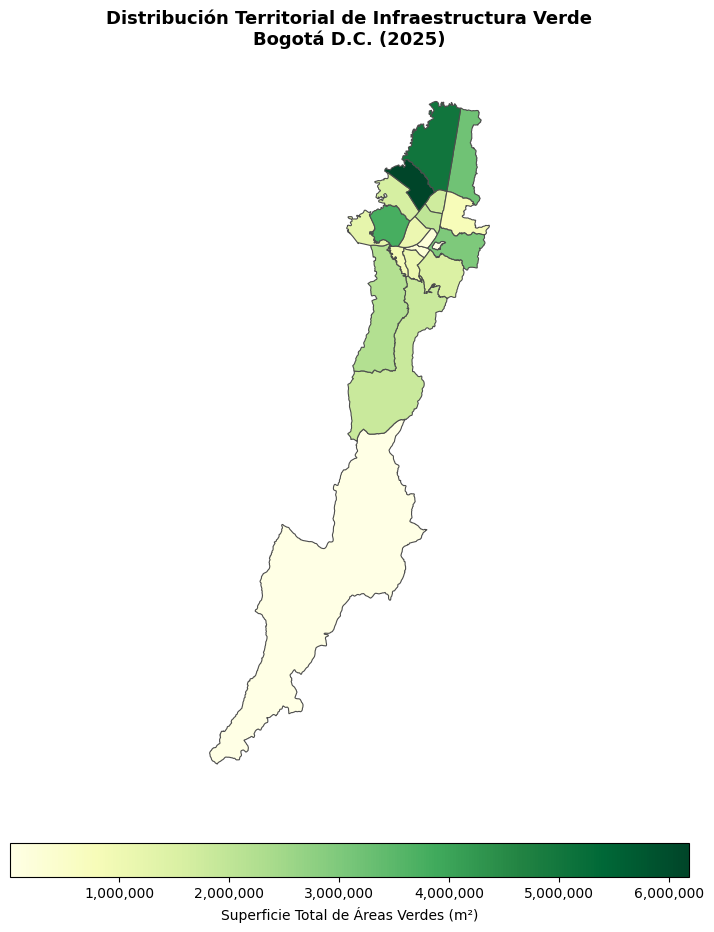

In [ ]:
# 5.1 Renderizar mapa coroplético de Infraestructura Verde (Toda Bogotá, n=20)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

map_gdf = master_gdf.copy()

# 5.2 Proyección a MAGNA-SIRGAS Origen Nacional (EPSG:9377) para evitar distorsión visual
if map_gdf.crs and map_gdf.crs.to_epsg() != 9377:
    map_gdf = map_gdf.to_crs(epsg=9377)

map_gdf.plot(
    column="total_green_area_sqm",
    cmap="YlGn",
    linewidth=0.8,
    ax=ax,
    edgecolor="0.3",
    legend=True,
    legend_kwds={
        "label": "Superficie Total de Áreas Verdes (m²)",
        "orientation": "horizontal",
        "shrink": 0.7,
        "pad": 0.05,
        "format": "{x:,.0f}",
    },
)

ax.set_title(
    "Distribución Territorial de Infraestructura Verde\nBogotá D.C. (2025)",
    fontsize=13,
    fontweight="bold",
)
ax.set_axis_off()
plt.tight_layout()

output_map_path = os.path.join(OUTPUTS_FIG_PATH, "map_green_infrastructure_bogota.png")
plt.savefig(output_map_path, dpi=300, bbox_inches="tight")
fig.set_dpi(100)
plt.show()

#### Verificación de valores nulos en área verde

Se confirma que ninguna localidad quedó con `total_green_area_sqm` nulo tras
la integración de fuentes en el Notebook 1, descartando así que algún valor
bajo visible en el mapa corresponda a un error de cruce en lugar de un dato
real.

In [ ]:
master_gdf[master_gdf["total_green_area_sqm"].isna()][["locality_clean", "total_green_area_sqm"]]

,locality_clean,total_green_area_sqm


### 6. Análisis demográfico: brecha de género en eventos de suicidio (2023-2025)

Se genera un gráfico de barras agrupadas que compara la incidencia de eventos de conducta suicida entre hombres y mujeres por localidad, ordenado de mayor a menor total de eventos, con el fin de visualizar tanto la magnitud absoluta como la brecha de género en cada localidad.

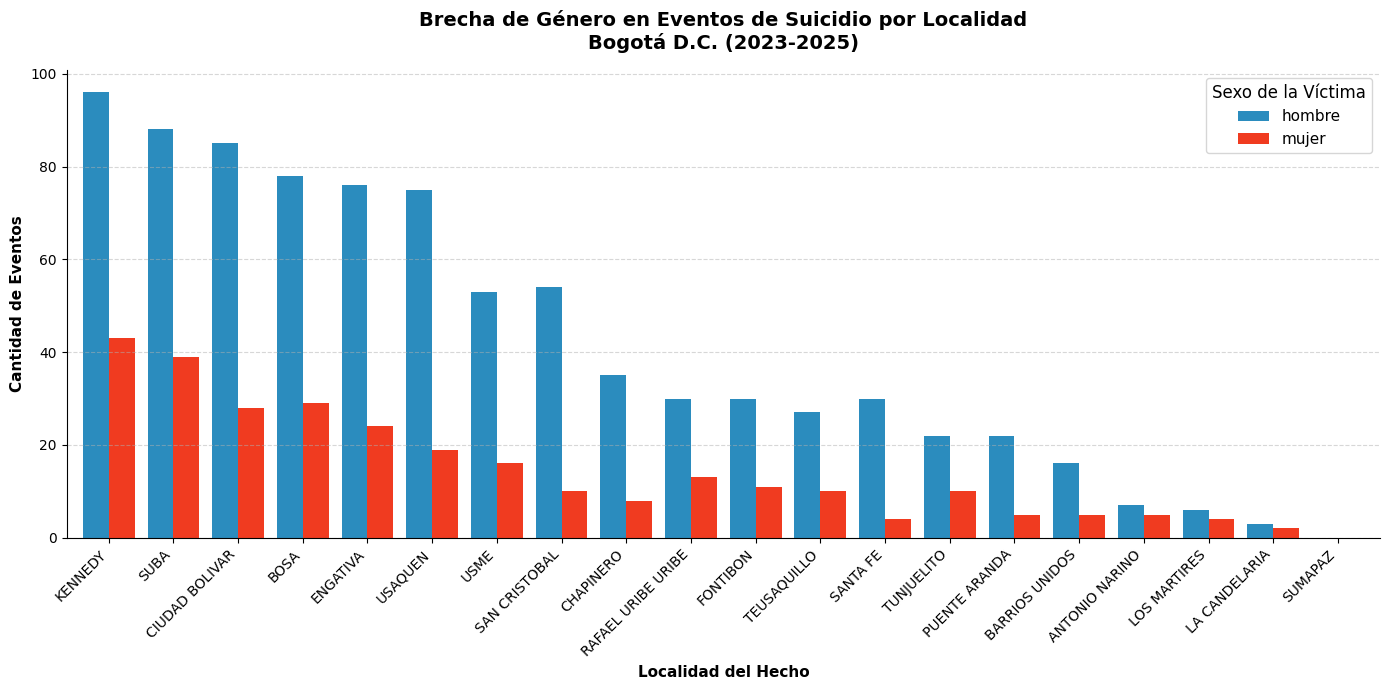

In [ ]:
# 6.1 Ordenar el dataframe de mayor a menor impacto y FORZAR el nuevo índice
plot_df = suicide_summary_df.sort_values(by="total_suicides_2023_2025", ascending=False).reset_index(drop=True)

# 6.2 Configurar el lienzo del gráfico y creación de barras agrupadas (Side-by-Side)
fig, ax = plt.subplots(figsize=(14, 7))

plot_df.plot(
    x="LOCALIDAD_DEL_HECHO",
    y=["hombre", "mujer"],
    kind="bar",
    color=["#2b8cbe", "#f03b20"], # Azul para Hombres, Rojo/Coral para Mujeres
    ax=ax,
    width=0.8
)

# 6.3 Limpieza y ajustes estéticos (Estilo minimalista)
ax.set_title(
    "Brecha de Género en Eventos de Suicidio por Localidad\nBogotá D.C. (2023-2025)",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Localidad del Hecho", fontsize=11, fontweight="bold")
ax.set_ylabel("Cantidad de Eventos", fontsize=11, fontweight="bold")
ax.legend(title="Sexo de la Víctima", fontsize=11, title_fontsize=12)

# Rotar las etiquetas del eje X para que no se superpongan
plt.xticks(rotation=45, ha="right")

# Líneas de cuadrícula solo horizontales para guiar el ojo
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Remover las líneas superior y derecha de la caja del gráfico (Descluttering)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# 6.4 Exportación de la imagen
output_bar_path = os.path.join(OUTPUTS_FIG_PATH, "bar_gender_gap_suicides.png")
plt.savefig(output_bar_path, dpi=300, bbox_inches="tight")
plt.show()

### 7. Efecto de la "carga de cuidado" en la salud autopercibida

Se agrupan las categorías de menores a cargo con muestra insuficiente (5, 6 y 7 menores, con n=10, n=2 y n=1 respectivamente) en una única categoría "5+", para evitar estimaciones inestables. Se visualiza la
proporción de salud deficiente reportada según el número de menores a cargo, anotando el tamaño de muestra (n) sobre cada barra para transparencia estadística.

In [ ]:
# Agrupar categorías con muestra insuficiente (5, 6 y 7 menores a cargo -> "5+")
perception_microdata_df["A4_agrupada"] = perception_microdata_df["A4"].apply(
    lambda x: "5+" if x >= 5 else str(int(x))
)

# Verificación rápida de los nuevos tamaños de grupo
perception_microdata_df.groupby("A4_agrupada")["poor_health"].agg(n="count", proporcion="mean")

,n,proporcion
A4_agrupada,,
0,8275,0.661511
1,2968,0.785040
2,1464,0.767760
3,311,0.662379
4,51,0.529412
5+,13,0.615385


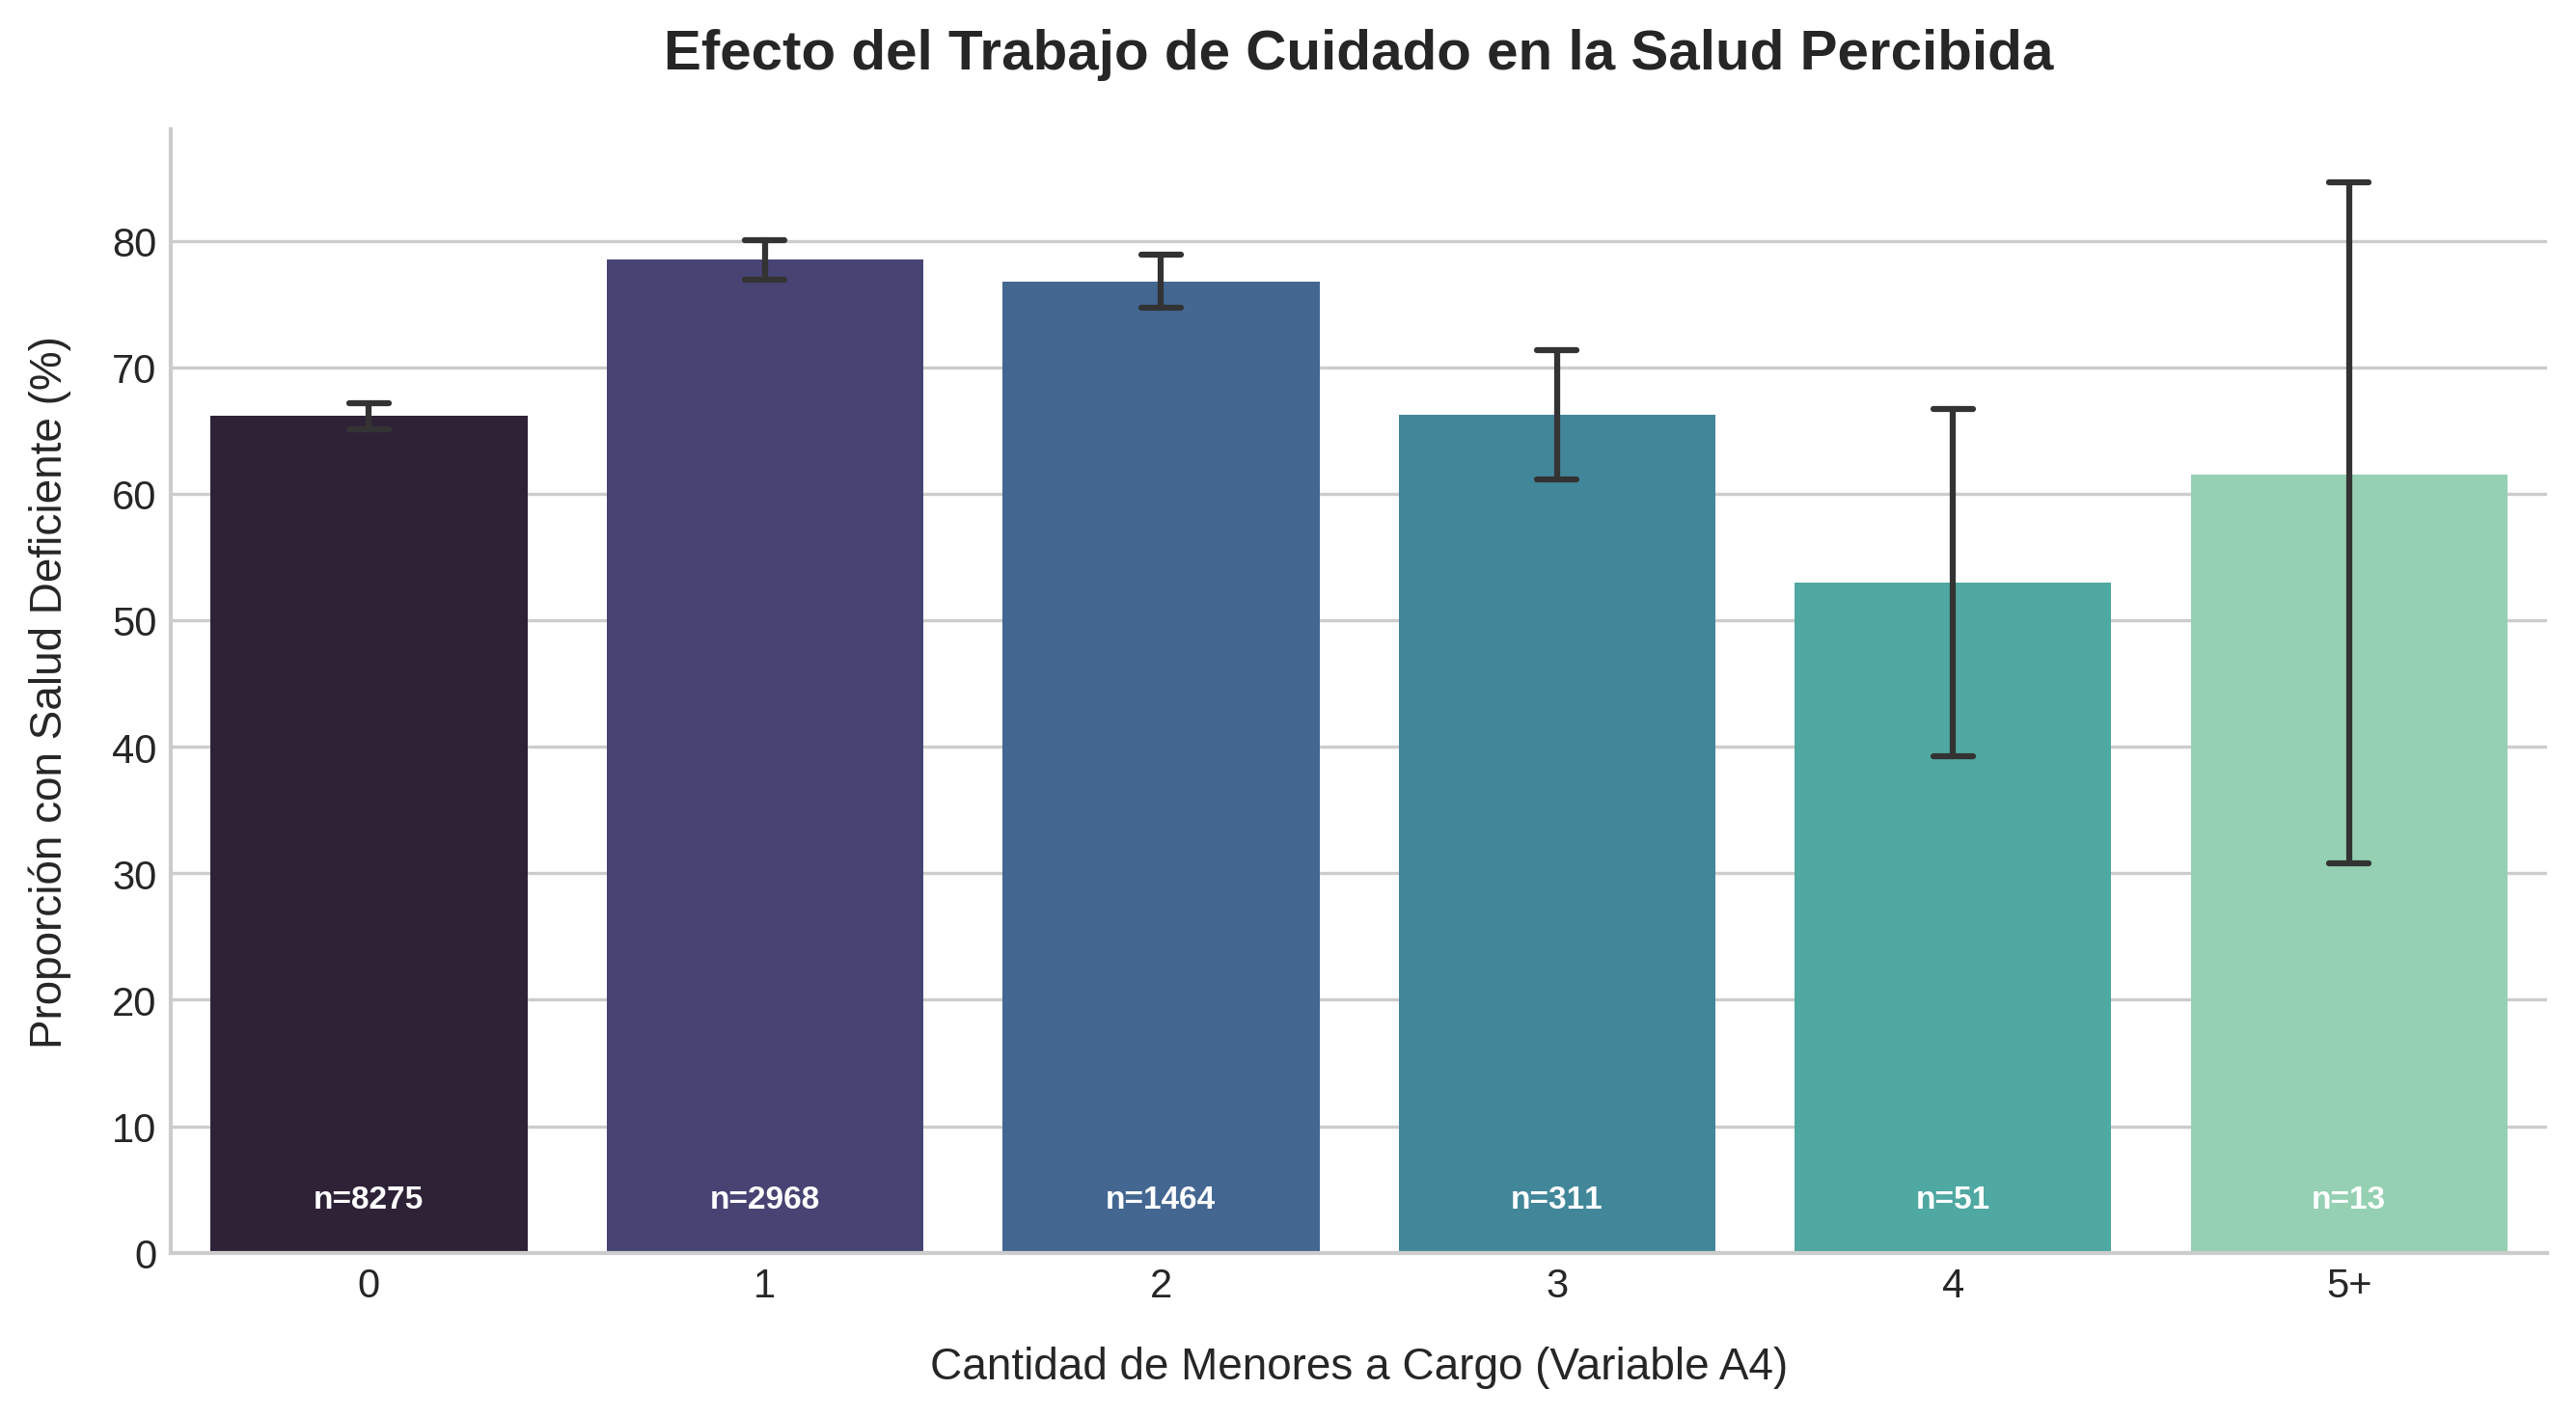

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(9, 5), dpi=300)

group_sizes = perception_microdata_df.groupby("A4_agrupada")["poor_health"].count()
order = ["0", "1", "2", "3", "4", "5+"]

sns.barplot(
    data=perception_microdata_df,
    x="A4_agrupada",
    y="poor_health",
    order=order,
    estimator=lambda x: sum(x) / len(x) * 100,
    errorbar=("ci", 95),
    palette="mako",
    capsize=0.1,
    err_kws={"linewidth": 1.5, "color": "#333333"},
    ax=ax,
)

for i, cat in enumerate(order):
    n = group_sizes.get(cat, 0)
    ax.text(i, 3, f"n={n}", ha="center", va="bottom", fontsize=8, color="white", fontweight="bold")

ax.set_title(
    "Efecto del Trabajo de Cuidado en la Salud Percibida",
    fontsize=14, pad=15, fontweight="bold",
)
ax.set_xlabel("Cantidad de Menores a Cargo (Variable A4)", fontsize=11, labelpad=10)
ax.set_ylabel("Proporción con Salud Deficiente (%)", fontsize=11, labelpad=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### 8. Contraste urbano-epidemiológico: infraestructura verde vs. tasa de suicidios

Se calcula la tasa de suicidios por 100,000 habitantes (2023-2025) usando la población promedio del periodo por localidad, y se analiza su correlación con la infraestructura verde disponible. A diferencia del análisis con valores absolutos, esta normalización por población controla el efecto de confusión por tamaño poblacional, permitiendo una comparación más apropiada
entre localidades de distinto tamaño.

Coeficiente de correlación (área verde vs. tasa por 100k): -0.082


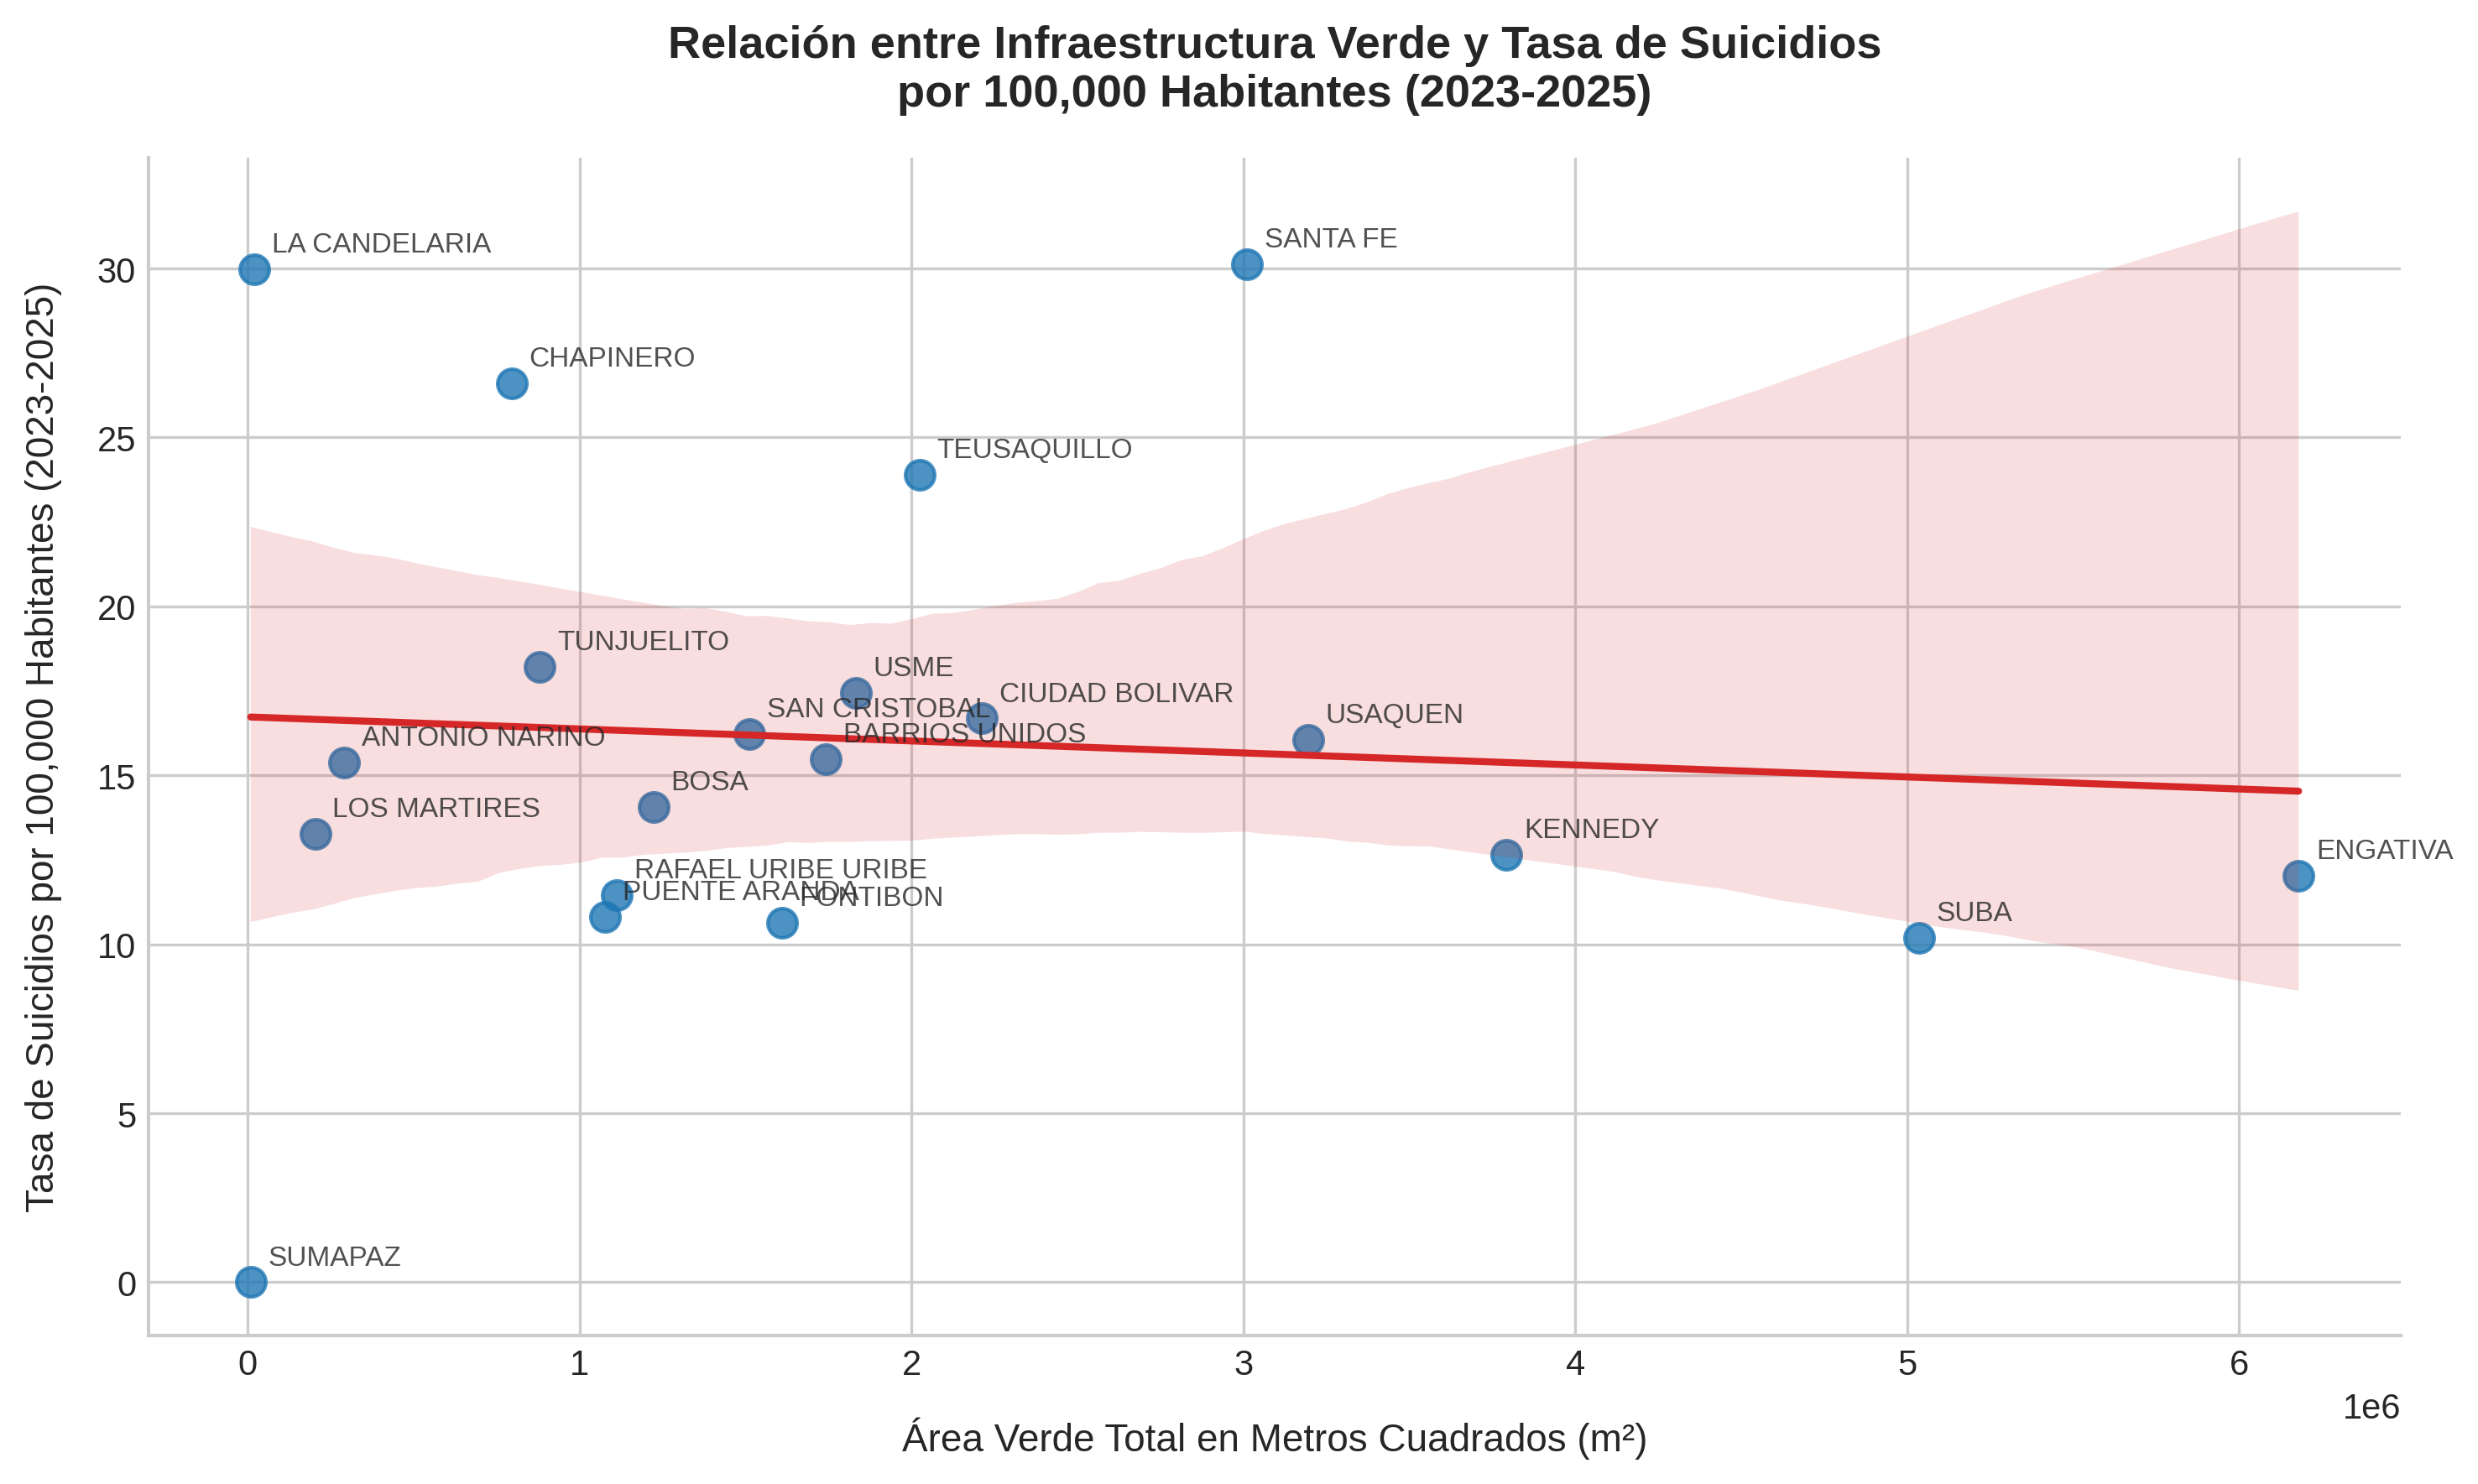

In [ ]:
# 8.1 Cálculo de la tasa de suicidios por 100,000 habitantes (2023-2025)
df_grafica = master_gdf.copy()
df_grafica["suicide_rate_per_100k"] = (
    df_grafica["total_suicides_2023_2025"]
    / df_grafica["avg_population_2023_2025"]
    * 100000
)

correlation_coef_rate = df_grafica["total_green_area_sqm"].corr(df_grafica["suicide_rate_per_100k"])
print(f"Coeficiente de correlación (área verde vs. tasa por 100k): {correlation_coef_rate:.3f}")

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

sns.regplot(
    data=df_grafica,
    x="total_green_area_sqm",
    y="suicide_rate_per_100k",
    scatter_kws={
        "s": 70,
        "color": "#1f77b4",
        "alpha": 0.8,
    },
    line_kws={"color": "#d62728", "linewidth": 2},
    ax=ax,
)

# 8.2 Etiquetar cada punto usando el nombre de la localidad
for i in range(len(df_grafica)):
    ax.annotate(
        df_grafica["locality_clean"].iloc[i],
        (
            df_grafica["total_green_area_sqm"].iloc[i],
            df_grafica["suicide_rate_per_100k"].iloc[i],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        alpha=0.8,
    )

ax.set_title(
    "Relación entre Infraestructura Verde y Tasa de Suicidios\npor 100,000 Habitantes (2023-2025)",
    fontsize=13,
    pad=15,
    fontweight="bold",
)
ax.set_xlabel(
    "Área Verde Total en Metros Cuadrados (m²)", fontsize=11, labelpad=10)
ax.set_ylabel(
    "Tasa de Suicidios por 100,000 Habitantes (2023-2025)", fontsize=11, labelpad=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

plt.show()

#### Prueba de significancia estadística de la correlación

Se calcula el coeficiente de correlación de Pearson entre área verde total y tasa de suicidios por 100,000 habitantes, junto con su p-valor, para determinar si la asociación observada es estadísticamente significativa o
podría deberse al azar dado el tamaño muestral reducido (n=20 localidades).

In [ ]:
corr_result = stats.pearsonr(df_grafica["total_green_area_sqm"], df_grafica["suicide_rate_per_100k"])
r_value = corr_result.statistic
p_value = corr_result.pvalue
n_obs = len(df_grafica)

significance_label = "significativa (p<0.05)" if p_value < 0.05 else "no significativa (p>=0.05)"

print(f"r = {r_value:.3f}")
print(f"p-value = {p_value:.3f}")
print(f"n = {n_obs}")
print(f"Interpretación: correlación {significance_label} dado el tamaño muestral.")

r = -0.082
p-value = 0.733
n = 20
Interpretación: correlación no significativa (p>=0.05) dado el tamaño muestral.


### 9. Exportación de artefactos finales para el dashboard

Se exportan los datasets y resultados requeridos por el dashboard interactivo (`app.py`): el resumen de suicidios por localidad, el resumen textual del modelo logit, los tamaños de grupo y los microdatos agrupados de la variable de menores a cargo.

In [ ]:
# Exportar el resumen de suicidios por localidad (para el bar chart de género)
suicide_summary_df.to_csv(f"{PROCESSED_DATA_PATH}suicide_summary.csv", index=False)

# Exportar el resumen del modelo logit (para el expander de estadísticas)
with open(f"{PROCESSED_DATA_PATH}logit_summary.txt", "w") as f:
    f.write(logit_model.summary().as_text())

# Exportar el dataframe agrupado para el gráfico de menores a cargo
group_sizes.to_csv(f"{PROCESSED_DATA_PATH}a4_group_sizes.csv")

perception_microdata_df[["A4_agrupada", "poor_health"]].to_csv(
    f"{PROCESSED_DATA_PATH}perception_a4.csv", index=False
)

## Conclusiones y limitaciones

**Hallazgos principales:**
- Existe una brecha de género marcada en los eventos de conducta suicida, con
  mayor incidencia en hombres en las 20 localidades analizadas.
- El número de menores de 18 años a cargo (A4) se asocia significativamente
  (p<0.05) con mayor probabilidad de salud percibida deficiente.
- El parentesco con el jefe del hogar (A6x2) es el determinante con mayor
  efecto marginal en el modelo, destacando el rol familiar como factor
  relevante más allá de variables demográficas básicas.

**Limitaciones:**
- El pseudo R² del modelo logit es bajo (~0.012), esperable en modelos de
  salud percibida con datos transversales de encuesta.
- La correlación entre área verde y suicidios es a nivel agregado (n=20
  localidades) y no controla por población, por lo que es susceptible a
  falacia ecológica.
- Categorías con muestra reducida en la encuesta fueron agrupadas para evitar
  estimaciones inestables.